In [20]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ["SPY","QQQ","IWM","TLT","GLD",
"EFA","EEM","VNQ","LQD","HYG"]

data = yf.download(tickers, start="2010-01-01")["Close"]
data.tail()


[*********************100%***********************]  10 of 10 completed


Ticker,EEM,EFA,GLD,HYG,IWM,LQD,QQQ,SPY,TLT,VNQ
Date,,,,,,,,,,
2026-03-06,57.320000,98.279999,473.510010,79.690002,250.889999,110.160004,599.750000,672.380005,88.459999,93.550003
2026-03-09,58.450001,98.989998,472.529999,80.169998,253.619995,110.820000,607.760010,678.270020,89.230003,93.760002
2026-03-10,58.680000,99.220001,477.859985,80.040001,253.360001,110.059998,607.770020,677.179993,88.279999,93.620003
2026-03-11,58.830002,99.010002,476.239990,79.860001,252.850006,109.160004,607.690002,676.330017,87.139999,92.650002
2026-03-12,56.950001,97.459999,466.880005,79.349998,247.410004,108.570000,597.260010,666.059998,86.970001,92.010002


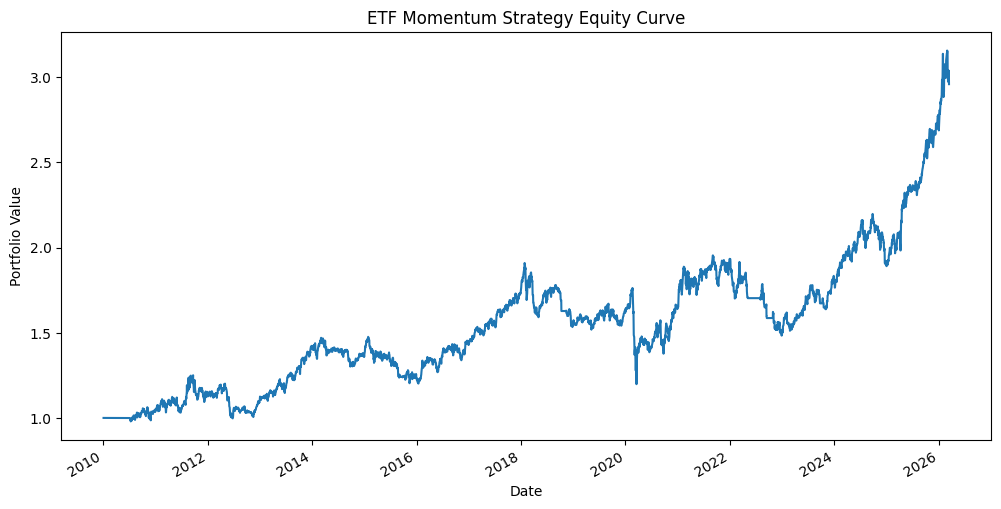

Sharpe Ratio: 0.54
Max Drawdown: -37.25%
CAGR: 6.94%


In [27]:

returns = data.pct_change()
momentum = data.pct_change(126)
ma100 = data.rolling(100).mean()

trend_filter = data > ma100
ranks = momentum.rank(axis=1, ascending=False)
top2 = ranks <= 2
signals = top2 & trend_filter

weights = signals.shift(1).astype(float)
weights = weights.div(weights.sum(axis=1), axis=0).fillna(0)

strategy_returns = (weights * returns).sum(axis=1)
equity = (1 + strategy_returns.fillna(0)).cumprod()

equity.plot(figsize=(12, 6), title="ETF Momentum Strategy Equity Curve")
plt.ylabel("Portfolio Value")
plt.show()

sharpe = strategy_returns.mean() / strategy_returns.std() * np.sqrt(252)
cummax = equity.cummax()
drawdown = (equity - cummax) / cummax
max_drawdown = drawdown.min()
cagr = equity.iloc[-1] ** (252 / len(equity)) - 1

print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Max Drawdown: {max_drawdown:.2%}")
print(f"CAGR: {cagr:.2%}")

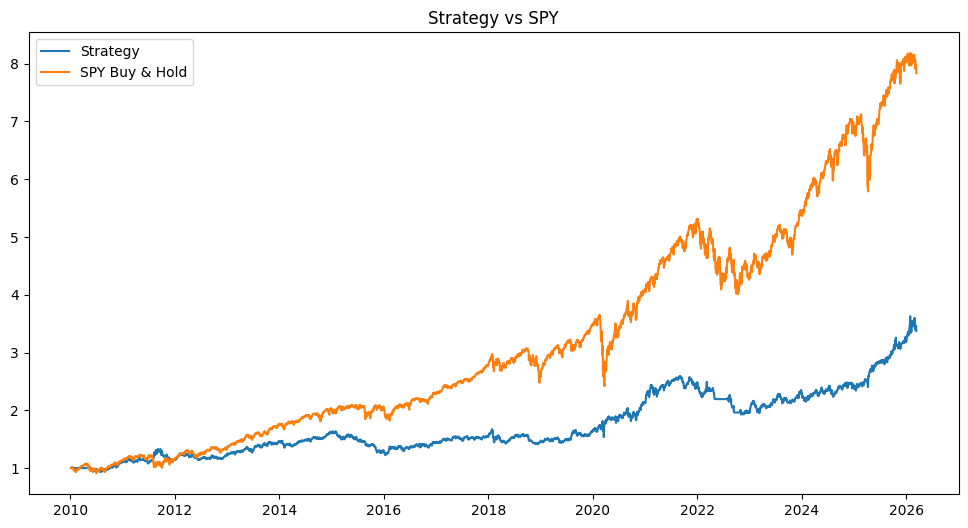

In [18]:
spy = data["SPY"].pct_change()
spy_equity = (1 + spy.fillna(0)).cumprod()

plt.figure(figsize=(12,6))
plt.plot(equity, label="Strategy")
plt.plot(spy_equity, label="SPY Buy & Hold")
plt.legend()
plt.title("Strategy vs SPY")
plt.show

turnover = weights.diff().abs().sum(axis=1)
cost = turnover * 0.001   # 0.1% trading cost

strategy_returns_cost = strategy_returns - cost
equity_cost = (1 + strategy_returns_cost.fillna(0)).cumprod()